# Chapter 15: Query Processing


## Core Question

SQL states what result is required. How does a DBMS turn that request into work that can
actually run, and what evidence can we use to explain the chosen access path?

Use this guide with the executable SQL lab cell.

Chapter 15 and Chapter 16 share one class meeting. The classroom core is deliberately
limited to reading query plans, distinguishing `SCAN` from `SEARCH`, recognizing join
order, and checking that two plans return the same result. Complete join algorithms,
materialization, pipelining, and I/O cost formulas are extensions.


## Connection to Other Chapters

Chapter 14 introduced indexes as access paths. This chapter shows how scans, index
searches, and joins appear in an executable plan. Chapter 16 then explains how an
optimizer uses statistics to choose among valid plans.

An unused index is not necessarily broken. The optimizer may estimate that another plan
will require less work.


## Prerequisites

- Explain the logical result of selection, projection, and an inner join.
- Write a basic query with `WHERE` and a join predicate.
- Recognize `SCAN`, `SEARCH`, and an index name in SQLite `EXPLAIN QUERY PLAN` output.


## Learning Objectives

After completing the classroom core, you should be able to:

1. Relate parsing, optimization, and evaluation in the query-processing workflow.
2. Distinguish a logical operation from a physical operator and an execution plan.
3. Identify a table scan, index search, and join order in a SQLite query plan.
4. Compare two plans only after confirming that their query results are equal.
5. State what a compact query plan does and does not prove.


## Teaching Summary

| Classroom topic | Worked evidence | Evidence to retain |
|---|---|---|
| SQL to execution plan | One selection before and after an index | SQL, result, and both plans |
| `SCAN` versus `SEARCH` | Title lookup in `ch15_course` | Access method and index name |
| Join order | Department-to-course lookup | Ordered plan explanation |
| Limits of plan evidence | Estimated plan versus observed result | One supported and one unsupported claim |


## 1. From SQL to Execution

A useful high-level workflow has three parts:

1. **Parsing and translation:** check syntax and names, then create an internal logical
   representation.
2. **Optimization:** compare valid alternatives and select an estimated low-cost plan.
3. **Evaluation:** execute the selected physical operators and produce the result.

Implementations differ across DBMS products, but this distinction prevents several
common mistakes. A misspelled column is a parsing problem. A legal query that uses a
table scan reflects an optimizer choice. Reading pages and producing rows are evaluation
work.


### Worked Example

```sql
SELECT course_id, title
FROM ch15_course
WHERE title = 'Course 04999';
```

The logical request is a selection followed by a projection. The SQL does not require a
particular index or join algorithm. The optimizer may choose a table scan or a title-index
search, and the execution engine performs that choice.


### Predict Before Checking

For each event, identify the stage most directly involved:

1. `course_idd` is not a valid column.
2. The query is valid, but the planner chooses a scan.
3. The DBMS reads rows and returns two columns.


### Interpretation

The answers are parsing/translation, optimization, and evaluation. Do not describe a
syntax error as an index failure.


## 2. Logical Operation, Physical Operator, and Plan

A logical operation describes the required relation. A physical operator describes how
the DBMS performs that work. A query-execution plan combines physical operators, access
paths, and their order.

The same logical selection can have different physical plans:

```text
Plan A: SCAN ch15_course -> test every title -> project two columns
Plan B: SEARCH the title index -> fetch matching row -> project two columns
```

The two plans are alternatives only if they return the same rows with the same duplicate
behavior. Their difference is physical work, not SQL meaning.


### Two access paths, the same requested row

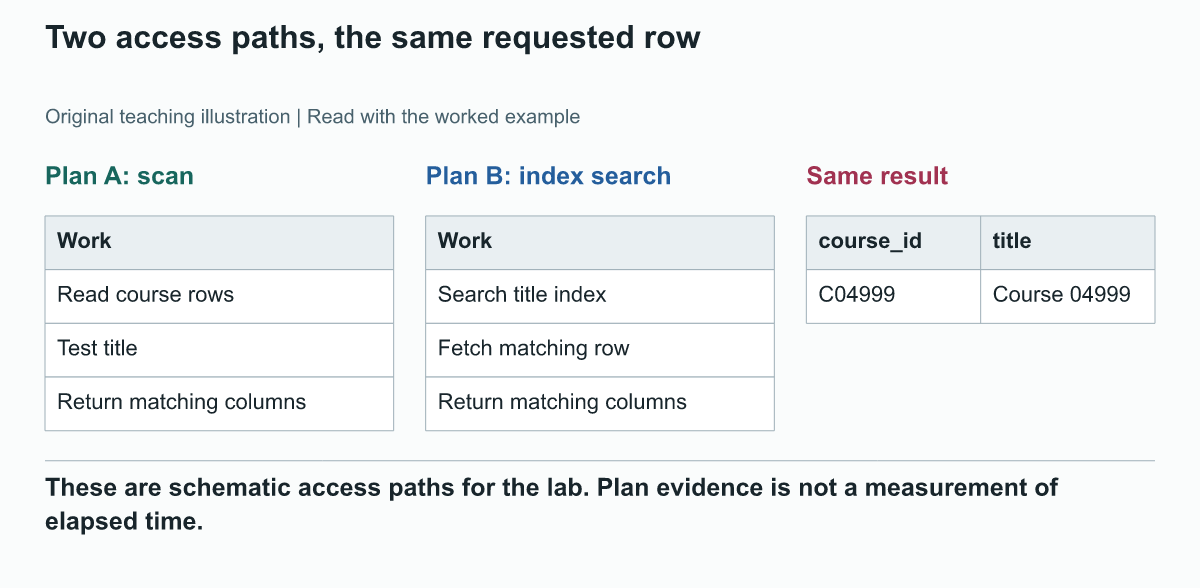

These are schematic access paths for the lab. Plan evidence is not a measurement of elapsed time.


### Lab Activity

Before running the lab, predict the access method in Phase 1 and Phase 2. Then execute
both phases and record:

- `SCAN` or `SEARCH`;
- the index name, if present;
- the predicate shown by the plan;
- the query result.


### Expected Interpretation

With the verified SQLite 3.45.3 environment, Phase 1 scans `ch15_course`. After the title
index is created, Phase 2 searches that index. The result remains
`C04999, Course 04999`.

If another SQLite version prints different wording, retain the complete plan and version.
Judge the access method from the actual output instead of editing it to match this guide.


## 3. `SCAN` and `SEARCH`

A table scan examines rows from the relation and can evaluate a general condition. An
index search uses an indexed predicate to narrow the access path. An index is most likely
to help when relatively few rows match, but index presence alone does not prove that an
index is faster.


### Worked Comparison

The lab contains 5,000 courses. A title predicate matches one row:

```sql
SELECT course_id, title
FROM ch15_course
WHERE title = 'Course 04999';
```

Without the title index, the plan reports a scan. After
`ch15_idx_course_title(title)` is created and statistics are available, the plan reports
an index search.

The predicate `credits = 3` matches 1,000 of 5,000 rows. That proportion alone does not
select the best plan. Projection width, row placement, cache state, and optimizer
estimates may also matter.


### Practice

1. Retain the before-and-after plans for the title query.
2. Confirm that both phases return the same result.
3. Calculate the matching proportion for `credits = 3`.
4. Write a hypothesis about scan or index use, followed by the plan evidence still needed.


### Check Criteria

The title query must change from a scan to a search in the verified environment without
changing its result. The credits answer must remain a testable hypothesis, not an
unqualified claim that an index will be faster.


## 4. Reading a Join Plan

For a nested-loop-style plan, one input is accessed first. Matching rows then drive access
to the next input. An index on the inner lookup key can avoid repeatedly scanning the
inner relation.


### A selective outer lookup drives the inner lookup

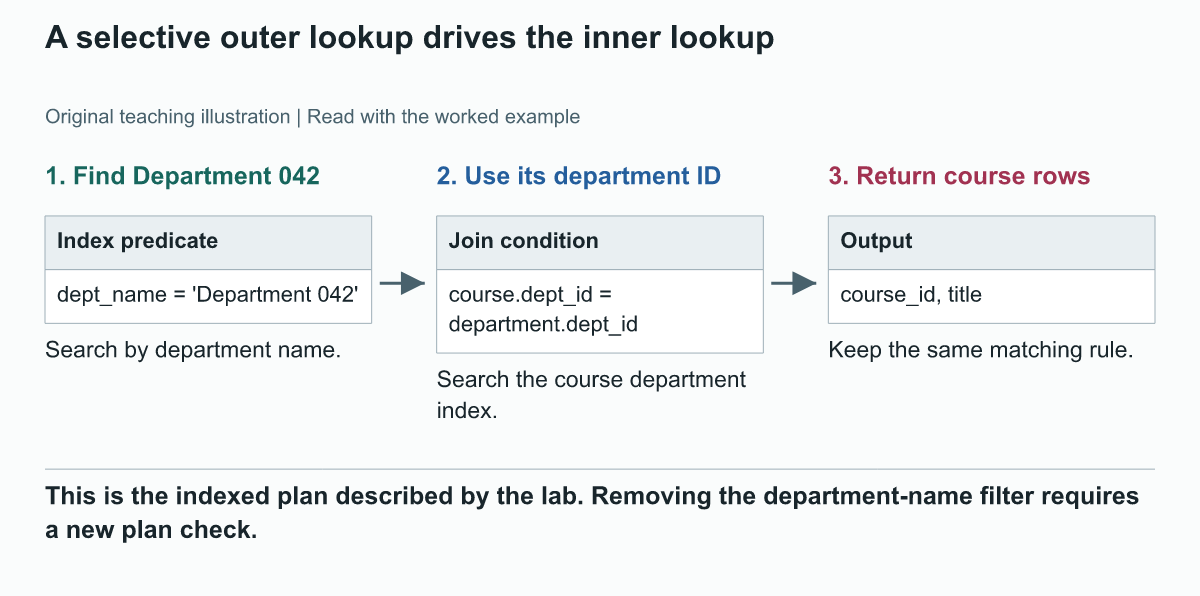

This is the indexed plan described by the lab. Removing the department-name filter requires a new plan check.


### Worked Example

```sql
SELECT c.course_id, c.title
FROM ch15_department AS d
JOIN ch15_course AS c ON c.dept_id = d.dept_id
WHERE d.dept_name = 'Department 042';
```

Phase 2 creates these indexes:

```sql
CREATE UNIQUE INDEX ch15_idx_department_name
ON ch15_department(dept_name);

CREATE INDEX ch15_idx_course_dept
ON ch15_course(dept_id);
```

The plan first searches for one department by name, then searches the course index by
that department identifier. The first small result drives the second lookup.


### Predict and Run

Before execution, predict which table should appear first in the indexed plan. Run both
phases and write the access order exactly as shown. Then remove the department-name
filter conceptually and decide whether the same order is still guaranteed to be best.


### Interpretation

The verified indexed plan has two `SEARCH` operations: department name first, course
department identifier second. Removing the selective filter changes the expected input
size, so the earlier conclusion cannot be reused without new statistics and a new plan.


## 5. Evidence and Limits

An optimizer normally compares estimated resource use, not a guaranteed wall-clock
time. Estimates may include row counts, storage access, CPU work, memory, and intermediate
results. Elapsed time also depends on cache state, concurrent load, storage, and the OS.

Before claiming that one plan is better, retain:

- the SQL and schema;
- row counts and relevant indexes;
- the DBMS version and statistics state;
- both query results;
- both plans;
- repeated measurements if elapsed time is discussed.

SQLite `EXPLAIN QUERY PLAN` does not report every internal cost, actual row count, buffer
read, or memory allocation. A plan can support a claim about its displayed access path,
but not every detail of runtime behavior.


## Extension: Additional Processing Concepts

These topics support further study but are not part of the Exam 3 classroom core.

- **Materialization:** store an intermediate result before the next operator reads it.
- **Pipelining:** pass rows directly from one operator to the next when possible.
- **Blocking work:** sorting may need many or all input rows before output can continue.
- **Additional join algorithms:** block nested-loop, merge join, and hash join.
- **Detailed cost models:** page-level I/O formulas and operator-specific estimates.

If a plan reports a temporary B-tree for `ORDER BY`, it supports the conclusion that this
plan performs separate sorting work. It does not reveal every buffering or disk detail.


## Common Errors

1. Treating SQL text order as the physical execution order.
2. Assuming that a logical join has only one physical implementation.
3. Claiming that an existing index must be used.
4. Comparing time without checking equal results and plans.
5. Treating estimated rows as measured rows.
6. Applying SQLite plan labels to every DBMS.
7. Calling nested loops slow without considering outer rows and inner access.


## Discussion and Individual Evidence

Compare two anonymous plans for the same SQL. First decide whether the results are
equivalent. Then explain the access methods, order, indexes, and temporary work. End with
one statement that the plan does not support.

Retain your SQL, data counts, before-and-after plans, result-equality check, line-by-line
plan explanation, and one corrected overclaim.


## Chapter Summary

Query processing turns a logical request into a physical plan. The classroom core is to
recognize scans, index searches, and join order while preserving result equivalence.
Plan evidence supports bounded conclusions; it does not make an index universally faster
or expose every runtime detail. Chapter 16 adds statistics and selectivity to this
reasoning.


## After-Class Continuation

For two queries of your choice, retain the schema, row counts, plan, and result check.
Read about complete join algorithms, materialization, pipelining, and I/O cost formulas as
extensions; they are not required derivations for the selected Chapter 15 assessment.


## Build and Inspect the Chapter Database

The executable cells use SQLite through Python's standard `sqlite3` module. Follow the
cells in order:

1. Open a database connection and enable foreign-key enforcement.
2. Execute the chapter's `CREATE TABLE` statements before inserting rows.
3. Load the synthetic example data.
4. Inspect the resulting tables, columns, primary keys, and foreign keys.
5. Check referential integrity before running the chapter queries.
6. Predict each query result, execute it, and explain any difference.

`DATABASE_NAME` is initially `:memory:`. The database disappears when its connection
closes; closing a browser tab alone may leave the kernel and connection running.
Change it to a filename such as `chapter_database.db` when you want SQLite to create a
persistent database in the notebook's working directory. Do not switch to a persistent
file until the in-memory version runs successfully from top to bottom.


In [1]:
import sqlite3

print(f"Python {__import__('sys').version.split()[0]}; SQLite {sqlite3.sqlite_version}")
DATABASE_NAME = ":memory:"  # Change to "chapter_database.db" to keep a database file.
connection = sqlite3.connect(DATABASE_NAME, isolation_level=None)
connection.execute("PRAGMA foreign_keys = ON")


def run_sql_script(connection, script, max_rows=20):
    """Execute a SQLite script and display result-producing statements."""
    buffer = ""
    for raw_line in script.splitlines():
        stripped = raw_line.strip()
        if stripped.startswith(".print"):
            message = stripped[len(".print"):].strip().strip("\"'")
            print(f"\n{message}")
            continue
        buffer += raw_line + "\n"
        if not sqlite3.complete_statement(buffer):
            continue
        statement = buffer.strip()
        buffer = ""
        if not statement:
            continue
        cursor = connection.execute(statement)
        if cursor.description:
            columns = [column[0] for column in cursor.description]
            rows = cursor.fetchmany(max_rows + 1)
            print(" | ".join(columns))
            for row in rows[:max_rows]:
                print(" | ".join("NULL" if value is None else str(value) for value in row))
            if len(rows) > max_rows:
                print(f"... additional rows omitted after {max_rows}")
    remaining = "\n".join(
        line for line in buffer.splitlines() if not line.strip().startswith("--")
    ).strip()
    if remaining:
        raise ValueError("The embedded SQL ends with an incomplete statement.")


def inspect_database(connection):
    """Display tables, columns, primary keys, foreign keys, and integrity status."""
    tables = [
        row[0]
        for row in connection.execute(
            "SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%' ORDER BY name"
        )
    ]
    print("Tables:", ", ".join(tables) if tables else "none")
    for table in tables:
        columns = connection.execute(f'PRAGMA table_info("{table}")').fetchall()
        primary_key = [row[1] for row in sorted(columns, key=lambda row: row[5]) if row[5]]
        print(f"\n{table}")
        print("  columns:", ", ".join(f"{row[1]} {row[2]}" for row in columns))
        print("  primary key:", ", ".join(primary_key) if primary_key else "none")
        for index_row in connection.execute(f'PRAGMA index_list("{table}")').fetchall():
            if index_row[2] and index_row[3] == "u":
                unique_columns = [
                    row[2]
                    for row in connection.execute(
                        f'PRAGMA index_info("{index_row[1]}")'
                    ).fetchall()
                ]
                print("  unique constraint:", ", ".join(unique_columns))
        foreign_keys = connection.execute(f'PRAGMA foreign_key_list("{table}")').fetchall()
        for foreign_key in foreign_keys:
            print(f"  foreign key: {foreign_key[3]} -> {foreign_key[2]}.{foreign_key[4]}")
    violations = connection.execute("PRAGMA foreign_key_check").fetchall()
    print("\nForeign-key check:", "PASS" if not violations else violations)


Python 3.12.9; SQLite 3.45.3


### Query-processing lab


In [2]:
SQL_1 = """PRAGMA foreign_keys = ON;
PRAGMA automatic_index = OFF;

-- === PHASE 1: SETUP WITHOUT SECONDARY INDEXES ===
DROP INDEX IF EXISTS ch15_idx_course_title;
DROP INDEX IF EXISTS ch15_idx_department_name;
DROP INDEX IF EXISTS ch15_idx_course_dept;
DROP TABLE IF EXISTS ch15_course;
DROP TABLE IF EXISTS ch15_department;

CREATE TABLE ch15_department (
    dept_id   INTEGER PRIMARY KEY,
    dept_name TEXT NOT NULL
);

CREATE TABLE ch15_course (
    course_id TEXT PRIMARY KEY,
    title     TEXT NOT NULL,
    dept_id   INTEGER NOT NULL,
    credits   INTEGER NOT NULL CHECK (credits BETWEEN 1 AND 5),
    FOREIGN KEY (dept_id) REFERENCES ch15_department(dept_id)
);

WITH RECURSIVE seq(n) AS (
    VALUES (1)
    UNION ALL
    SELECT n + 1 FROM seq WHERE n < 100
)
INSERT INTO ch15_department(dept_id, dept_name)
SELECT n, printf('Department %03d', n)
FROM seq;

WITH RECURSIVE seq(n) AS (
    VALUES (1)
    UNION ALL
    SELECT n + 1 FROM seq WHERE n < 5000
)
INSERT INTO ch15_course(course_id, title, dept_id, credits)
SELECT printf('C%05d', n),
       printf('Course %05d', n),
       ((n - 1) % 100) + 1,
       ((n - 1) % 5) + 1
FROM seq;

ANALYZE;

SELECT COUNT(*) AS departments FROM ch15_department;
SELECT COUNT(*) AS courses FROM ch15_course;
SELECT COUNT(*) AS credit_three_courses
FROM ch15_course WHERE credits = 3;

EXPLAIN QUERY PLAN
SELECT course_id, title
FROM ch15_course
WHERE title = 'Course 04999';

EXPLAIN QUERY PLAN
SELECT c.course_id, c.title
FROM ch15_department AS d
JOIN ch15_course AS c ON c.dept_id = d.dept_id
WHERE d.dept_name = 'Department 042';

-- === PHASE 2: ADD SELECTION AND JOIN ACCESS PATHS ===
CREATE INDEX ch15_idx_course_title
ON ch15_course(title);

CREATE UNIQUE INDEX ch15_idx_department_name
ON ch15_department(dept_name);

CREATE INDEX ch15_idx_course_dept
ON ch15_course(dept_id);

ANALYZE;

EXPLAIN QUERY PLAN
SELECT course_id, title
FROM ch15_course
WHERE title = 'Course 04999';

SELECT course_id, title
FROM ch15_course
WHERE title = 'Course 04999';

EXPLAIN QUERY PLAN
SELECT c.course_id, c.title
FROM ch15_department AS d
JOIN ch15_course AS c ON c.dept_id = d.dept_id
WHERE d.dept_name = 'Department 042';

SELECT COUNT(*) AS department_042_courses
FROM ch15_department AS d
JOIN ch15_course AS c ON c.dept_id = d.dept_id
WHERE d.dept_name = 'Department 042';

-- This query needs title order. Record whether the plan reports temporary sorting.
EXPLAIN QUERY PLAN
SELECT c.course_id, c.title
FROM ch15_department AS d
JOIN ch15_course AS c ON c.dept_id = d.dept_id
WHERE d.dept_name = 'Department 042'
ORDER BY c.title;
"""


In [3]:
run_sql_script(connection, SQL_1)


departments
100
courses
5000
credit_three_courses
1000
id | parent | notused | detail
2 | 0 | 0 | SCAN ch15_course
id | parent | notused | detail
3 | 0 | 0 | SCAN c
6 | 0 | 0 | BLOOM FILTER ON d (dept_id=?)
14 | 0 | 0 | SEARCH d USING INTEGER PRIMARY KEY (rowid=?)
id | parent | notused | detail
3 | 0 | 0 | SEARCH ch15_course USING INDEX ch15_idx_course_title (title=?)
course_id | title
C04999 | Course 04999
id | parent | notused | detail
4 | 0 | 0 | SEARCH d USING COVERING INDEX ch15_idx_department_name (dept_name=?)
8 | 0 | 0 | SEARCH c USING INDEX ch15_idx_course_dept (dept_id=?)
department_042_courses
50
id | parent | notused | detail
5 | 0 | 0 | SEARCH d USING COVERING INDEX ch15_idx_department_name (dept_name=?)
9 | 0 | 0 | SEARCH c USING INDEX ch15_idx_course_dept (dept_id=?)
19 | 0 | 0 | USE TEMP B-TREE FOR ORDER BY


### Inspect the Database You Created

Read the output as a schema check: confirm the table names, column types, primary-key order, foreign-key direction, and integrity result.


In [4]:
inspect_database(connection)


Tables: ch15_course, ch15_department

ch15_course
  columns: course_id TEXT, title TEXT, dept_id INTEGER, credits INTEGER
  primary key: course_id
  foreign key: dept_id -> ch15_department.dept_id

ch15_department
  columns: dept_id INTEGER, dept_name TEXT
  primary key: dept_id

Foreign-key check: PASS


### Reproducibility Check


In [5]:
assert connection.execute("SELECT COUNT(*) FROM ch15_department").fetchone()[0] == 100
assert connection.execute("SELECT COUNT(*) FROM ch15_course").fetchone()[0] == 5000
assert connection.execute("PRAGMA foreign_key_check").fetchall() == []
print("Notebook checks passed.")


Notebook checks passed.


In [6]:
connection.close()
print("Database connection closed.")


Database connection closed.
